Data Loading & Exploration                                           

• Objective
- The goal of this notebook is to load the Online Retail dataset, understand its structure, identify data quality issues, and perform an initial exploration before data preprocessing.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [2]:
# Load the dataset
df = pd.read_csv("../data/OnlineRetail.csv", encoding="latin1")

In [3]:
# Check the number of rows and columns
df.shape

(541909, 8)

In [4]:
# Display the first five rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
# Display information about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 69.3 MB


• Data Type Conversion

- The 'InvoiceDate' column is converted to a datetime format to enable time-based analysis.  
- The 'CustomerID' column is converted to an integer type because it represents an identifier rather than a decimal value.

In [6]:
# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Convert CustomerID to nullable integer
df["CustomerID"] = df["CustomerID"].astype("Int64")

In [7]:
# Display the date range of the dataset
df["InvoiceDate"].agg(["min", "max"])

min   2022-12-01 08:26:00
max   2023-12-09 12:50:00
Name: InvoiceDate, dtype: datetime64[us]

• Missing Values

- Before cleaning the dataset, let's identify the columns that contain missing values.

In [8]:
# Check missing values

missing_df = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing (%)": (df.isnull().sum() / len(df) * 100).round(2)
})

# Display only columns with missing values
missing_df[missing_df["Missing Count"] > 0]

,Missing Count,Missing (%)
Description,1454,0.27
CustomerID,135080,24.93


• Observation

- 'CustomerID' contains a large number of missing values because many customers made purchases without creating an account.
- 'Description' has only a few missing values.
- These missing values will be handled during data preprocessing.

• Duplicate Records

- Duplicate rows can lead to incorrect analysis and should be identified before preprocessing.

In [9]:
# Count duplicate rows

df.duplicated().sum()

np.int64(5268)

• Statistical Summary

- Let's examine the numerical columns to understand their distribution and identify any unusual values.

In [10]:
# Summary statistics for numerical columns

df[["Quantity", "UnitPrice"]].describe().round(2)

,Quantity,UnitPrice
count,541909.00,541909.00
mean,9.55,4.61
std,218.08,96.76
min,-80995.00,-11062.06
25%,1.00,1.25
50%,3.00,2.08
75%,10.00,4.13
max,80995.00,38970.00


• Observation

- Negative values in **Quantity** represent returned or cancelled items.
- A **UnitPrice** of zero indicates free items or adjustments.
- These records will be handled during data preprocessing.

• Cancelled Transactions

- Invoices starting with 'C' indicate cancelled transactions.

In [11]:
# Find cancelled transactions

cancelled = df[df["InvoiceNo"].astype(str).str.startswith("C")]

cancelled.shape

(9288, 8)

• Unique Values

- Let's check how many unique invoices, products, customers, and countries are present in the dataset.

In [12]:
# Count unique values in important columns

pd.DataFrame({
    "Unique Count": [
        df["InvoiceNo"].nunique(),
        df["StockCode"].nunique(),
        df["CustomerID"].nunique(),
        df["Country"].nunique()
    ]
},
index=[
    "Invoices",
    "Products",
    "Customers",
    "Countries"
])

,Unique Count
Invoices,25900
Products,4070
Customers,4372
Countries,38


• Top Countries

- Let's identify the countries with the highest number of transactions.

In [13]:
# Top 10 countries by number of transactions

top_countries = df["Country"].value_counts().head(10)

top_countries

Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

• Dataset Overview Visualizations

- Visualizations help us quickly understand the dataset before moving to data preprocessing.

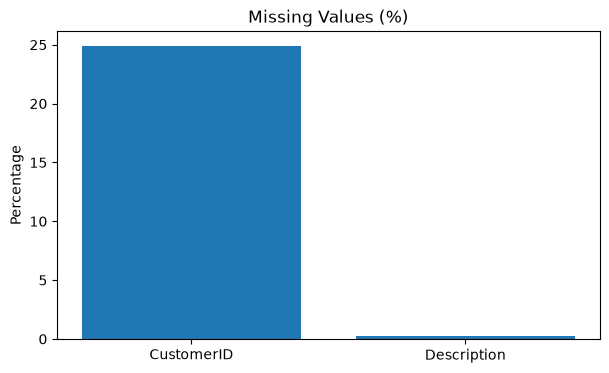

In [14]:
# Missing values by percentage

missing_percent = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_percent = missing_percent[
    missing_percent > 0
]

plt.figure(figsize=(7,4))

plt.bar(
    missing_percent.index,
    missing_percent.values
)

plt.title("Missing Values (%)")

plt.ylabel("Percentage")

plt.xticks(rotation=0)

plt.show()

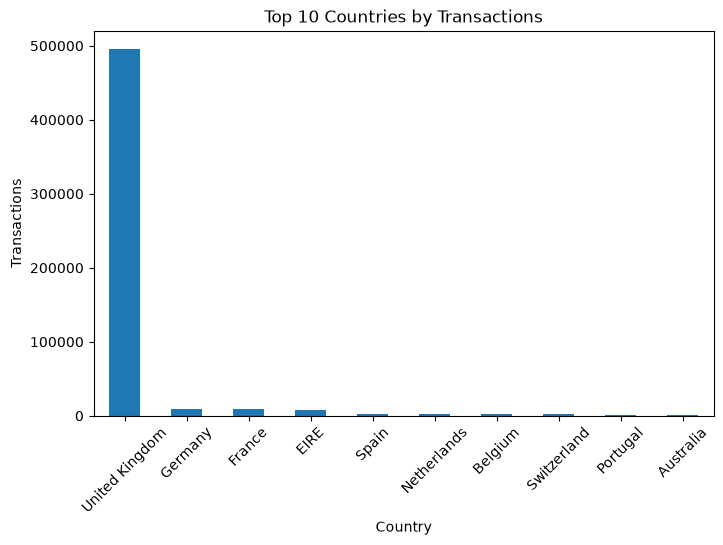

In [15]:
# Top 10 countries by transaction count

plt.figure(figsize=(8,5))

top_countries.plot(kind="bar")

plt.title("Top 10 Countries by Transactions")

plt.xlabel("Country")

plt.ylabel("Transactions")

plt.xticks(rotation=45)

plt.show()

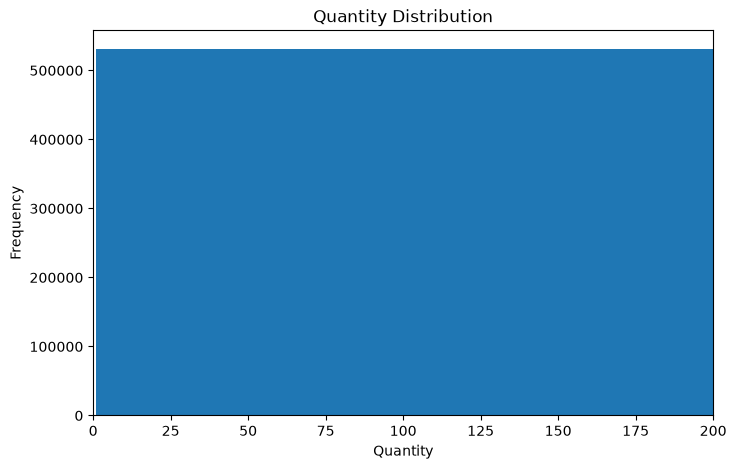

In [16]:
# Distribution of purchased quantity

positive_quantity = df[df["Quantity"] > 0]

plt.figure(figsize=(8,5))

plt.hist(
    positive_quantity["Quantity"],
    bins=50
)

plt.xlim(0,200)

plt.title("Quantity Distribution")

plt.xlabel("Quantity")

plt.ylabel("Frequency")

plt.show()

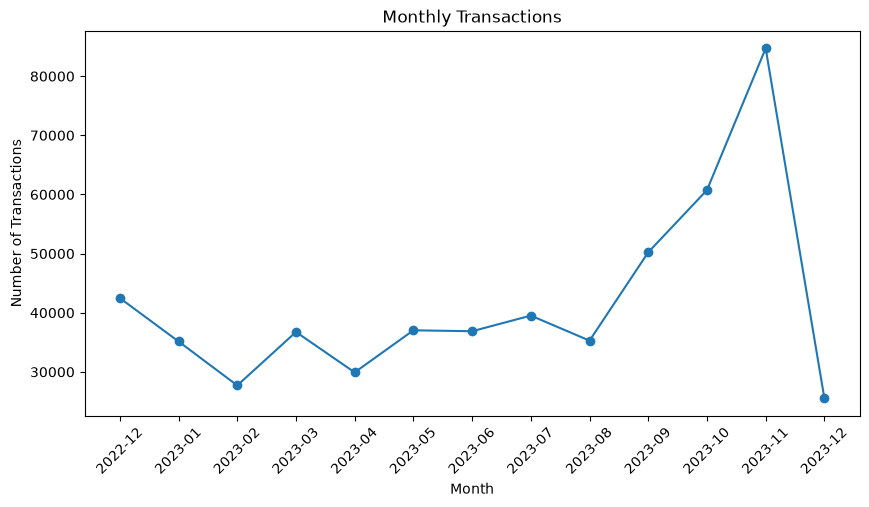

In [17]:
# Monthly transaction count

monthly_transactions = (
    df.groupby(df["InvoiceDate"].dt.to_period("M"))
    .size()
)

monthly_transactions.index = monthly_transactions.index.astype(str)

plt.figure(figsize=(10,5))

plt.plot(
    monthly_transactions.index,
    monthly_transactions.values,
    marker="o"
)

plt.title("Monthly Transactions")

plt.xlabel("Month")

plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.show()

• Key Findings

- The dataset contains over **500,000** transaction records from **38 countries**.
- 'CustomerID' has a significant number of missing values.
- Duplicate records are present and will be removed during preprocessing.
- Some invoices are cancelled and will be excluded from further analysis.
- Negative quantities indicate returned products.
- The dataset is now ready for data preprocessing.